<a href="https://colab.research.google.com/github/Subham-Singh-369/OIBSIP/blob/main/DataScience-Task4-EmailSpamDetection/Email_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (1).csv


In [75]:
import pandas as pd
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [76]:
# Keep only the required columns
df = df[['v1', 'v2']]

# Rename columns for better readability
df.columns = ['label', 'message']

In [77]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [78]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 5572
Number of Columns: 2


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [80]:
df.isnull().sum()

,0
label,0
message,0


In [81]:
print("Duplicate Messages:", df.duplicated().sum())

Duplicate Messages: 403


In [82]:
df = df.drop_duplicates()

In [83]:
print(df.shape)

(5169, 2)


In [84]:
df["label"].value_counts()

,count
label,
ham,4516
spam,653


In [85]:
(df["label"].value_counts(normalize=True) * 100).round(2)

,proportion
label,
ham,87.37
spam,12.63


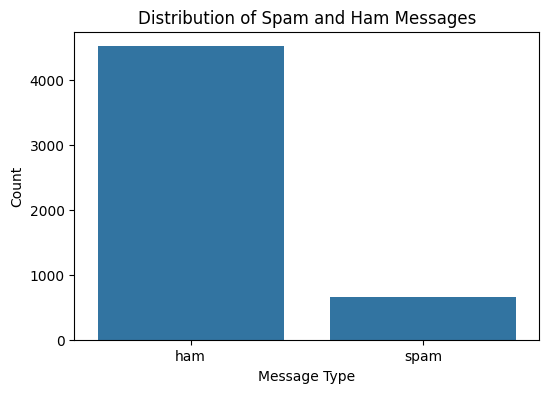

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [87]:
df["message_length"] = df["message"].apply(len)

df["message_length"].describe()

,message_length
count,5169.000000
mean,78.977945
std,58.236293
min,2.000000
25%,36.000000
50%,60.000000
75%,117.000000
max,910.000000


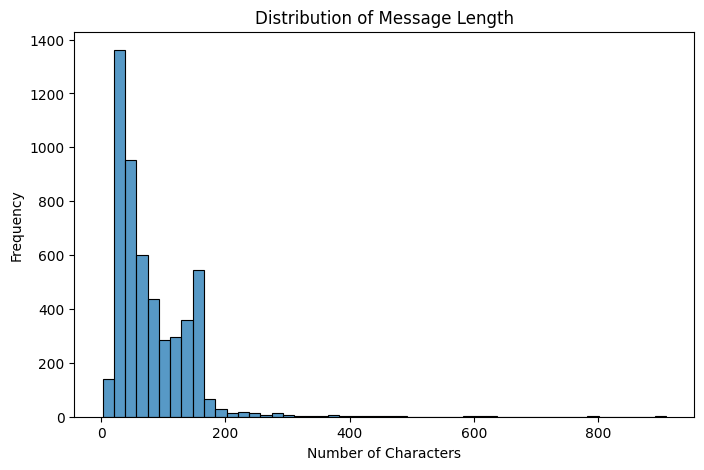

In [88]:
plt.figure(figsize=(8,5))

sns.histplot(df["message_length"], bins=50)

plt.title("Distribution of Message Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

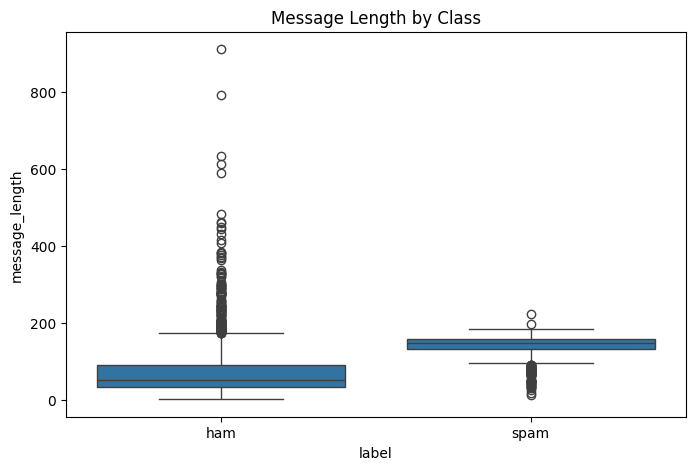

In [89]:
plt.figure(figsize=(8,5))

sns.boxplot(x="label", y="message_length", data=df)

plt.title("Message Length by Class")

plt.show()

## Exploratory Data Analysis (EDA)

Before training the machine learning models, the dataset was explored to understand its structure and quality.

- The dataset contains **5,572 SMS messages**.
- Each message is labeled as either **ham (legitimate)** or **spam**.
- Missing values and duplicate records were checked.
- The distribution of spam and ham messages was analyzed.
- Message lengths were examined to understand whether spam and ham messages differ in size.

This step helps identify data quality issues and provides useful insights before preprocessing and model training.

In [90]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [91]:
stop_words = set(stopwords.words('english'))

In [92]:
def preprocess(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Split sentence into words
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back into a sentence
    return " ".join(words)

In [93]:
df["clean_message"] = df["message"].apply(preprocess)

In [94]:
df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling 3 weeks word back id like ...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile 11 months u r entitled update latest co...


In [95]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

## Text Preprocessing

Text preprocessing is an important step in Natural Language Processing (NLP). Raw text often contains uppercase letters, punctuation, and common words that do not contribute much to classification.

The following preprocessing steps were performed:

- Converted all text to lowercase.
- Removed punctuation and special characters.
- Removed English stopwords using the NLTK library.
- Stored the cleaned text in a new column (`clean_message`) while preserving the original messages.

These steps help reduce noise in the dataset and improve the quality of features used for machine learning.

## TF-IDF Vectorization

TF-IDF (Term Frequency–Inverse Document Frequency) is a feature extraction technique used in Natural Language Processing (NLP).

- **Term Frequency (TF)** measures how often a word appears in a document.
- **Inverse Document Frequency (IDF)** reduces the importance of words that appear frequently across many documents.

By combining TF and IDF, the algorithm assigns higher weights to informative words (such as "winner", "free", "claim") and lower weights to common words (such as "the", "is", "and"). The resulting numerical vectors are then used as input for machine learning models.

In [96]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

In [97]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=3000)

In [98]:
X = vectorizer.fit_transform(df["clean_message"])

y = df["label"]

In [99]:
print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (5169, 3000)


In [100]:
print(vectorizer.get_feature_names_out()[:20])

['020603' '0207' '02073162414' '020903' '021' '050703' '0578'
 '0776xxxxxxx' '07xxxxxxxxx' '0800' '08000839402' '08000930705'
 '08001950382' '08002986906' '0845' '0870' '08701417012' '08707509020'
 '08712300220' '08712405020']


In [101]:
feature_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

feature_df.head()

,020603,0207,02073162414,020903,021,050703,0578,0776xxxxxxx,07xxxxxxxxx,0800,...,youll,youre,youve,yr,yrs,yummy,yun,yup,zed,zoe
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [102]:
from sklearn.model_selection import train_test_split

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [104]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (4135, 3000)
Testing Data : (1034, 3000)


In [105]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [106]:
y_pred_nb = nb_model.predict(X_test)

In [107]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [108]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [109]:
def evaluate_model(model_name, y_true, y_pred):

    print("=" * 50)
    print(f"{model_name} Evaluation")
    print("=" * 50)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Ham','Spam'],
        yticklabels=['Ham','Spam']
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    return accuracy, precision, recall, f1

Multinomial Naive Bayes Evaluation
Accuracy : 0.9758
Precision: 0.9818
Recall   : 0.8244
F1 Score : 0.8963

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.98      0.82      0.90       131

    accuracy                           0.98      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.98      0.98      0.97      1034



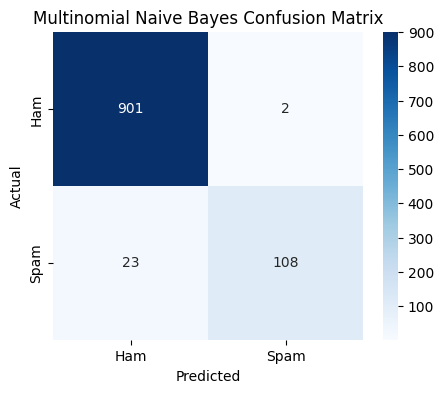

In [110]:
nb_results = evaluate_model(
    "Multinomial Naive Bayes",
    y_test,
    y_pred_nb
)

Logistic Regression Evaluation
Accuracy : 0.9545
Precision: 0.9773
Recall   : 0.6565
F1 Score : 0.7854

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       903
           1       0.98      0.66      0.79       131

    accuracy                           0.95      1034
   macro avg       0.96      0.83      0.88      1034
weighted avg       0.96      0.95      0.95      1034



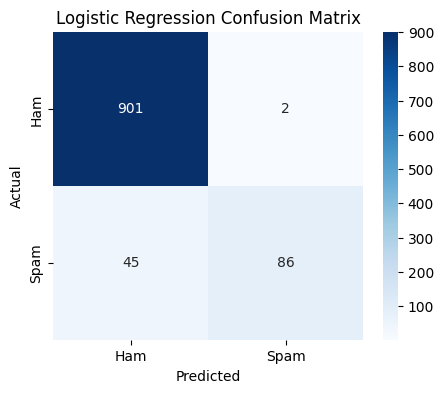

In [111]:
lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

In [112]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy":[nb_results[0], lr_results[0]],
    "Precision":[nb_results[1], lr_results[1]],
    "Recall":[nb_results[2], lr_results[2]],
    "F1 Score":[nb_results[3], lr_results[3]]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.975822,0.981818,0.824427,0.896266
1,Logistic Regression,0.954545,0.977273,0.656489,0.785388


In [113]:
from wordcloud import WordCloud

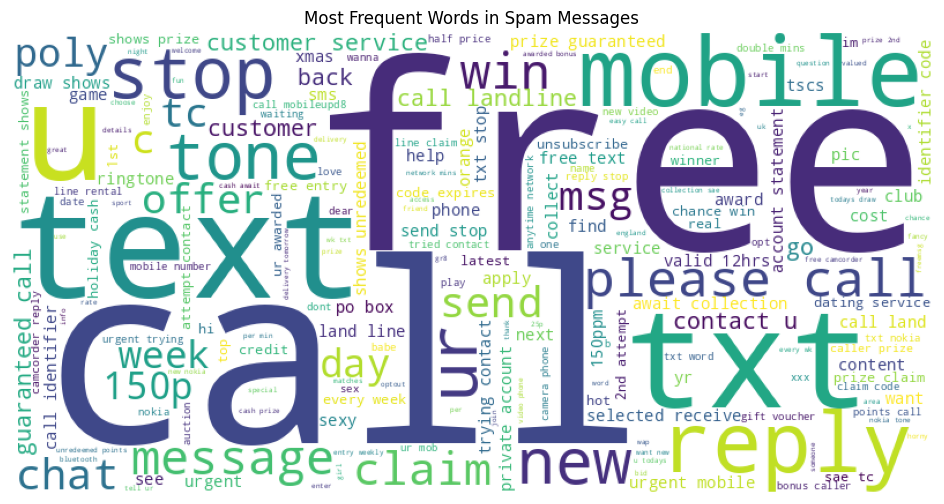

In [114]:
spam_words = " ".join(
    df[df["label"] == 1]["clean_message"]
)

spam_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_words)

plt.figure(figsize=(12,6))

plt.imshow(spam_wc)

plt.axis("off")

plt.title("Most Frequent Words in Spam Messages")

plt.show()

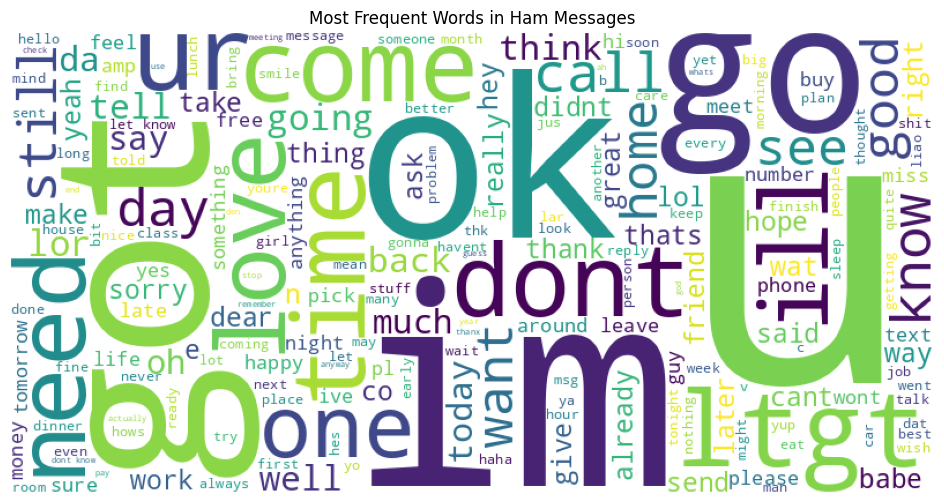

In [115]:
ham_words = " ".join(
    df[df["label"] == 0]["clean_message"]
)

ham_wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_words)

plt.figure(figsize=(12,6))

plt.imshow(ham_wc)

plt.axis("off")

plt.title("Most Frequent Words in Ham Messages")

plt.show()